In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent   # car notebook est dans notebook/ et pas dans le root du projet
sys.path.insert(0, str(PROJECT_ROOT))

# Carte émission de CO2 par habitant en europe (2021)

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.20
   Étendue: [-61.15, 46.70, -12.57, 95.28]
🖼️ Image ajoutée
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.27
   Étendue: [-14.64, 44.64, 22.86, 82.14]


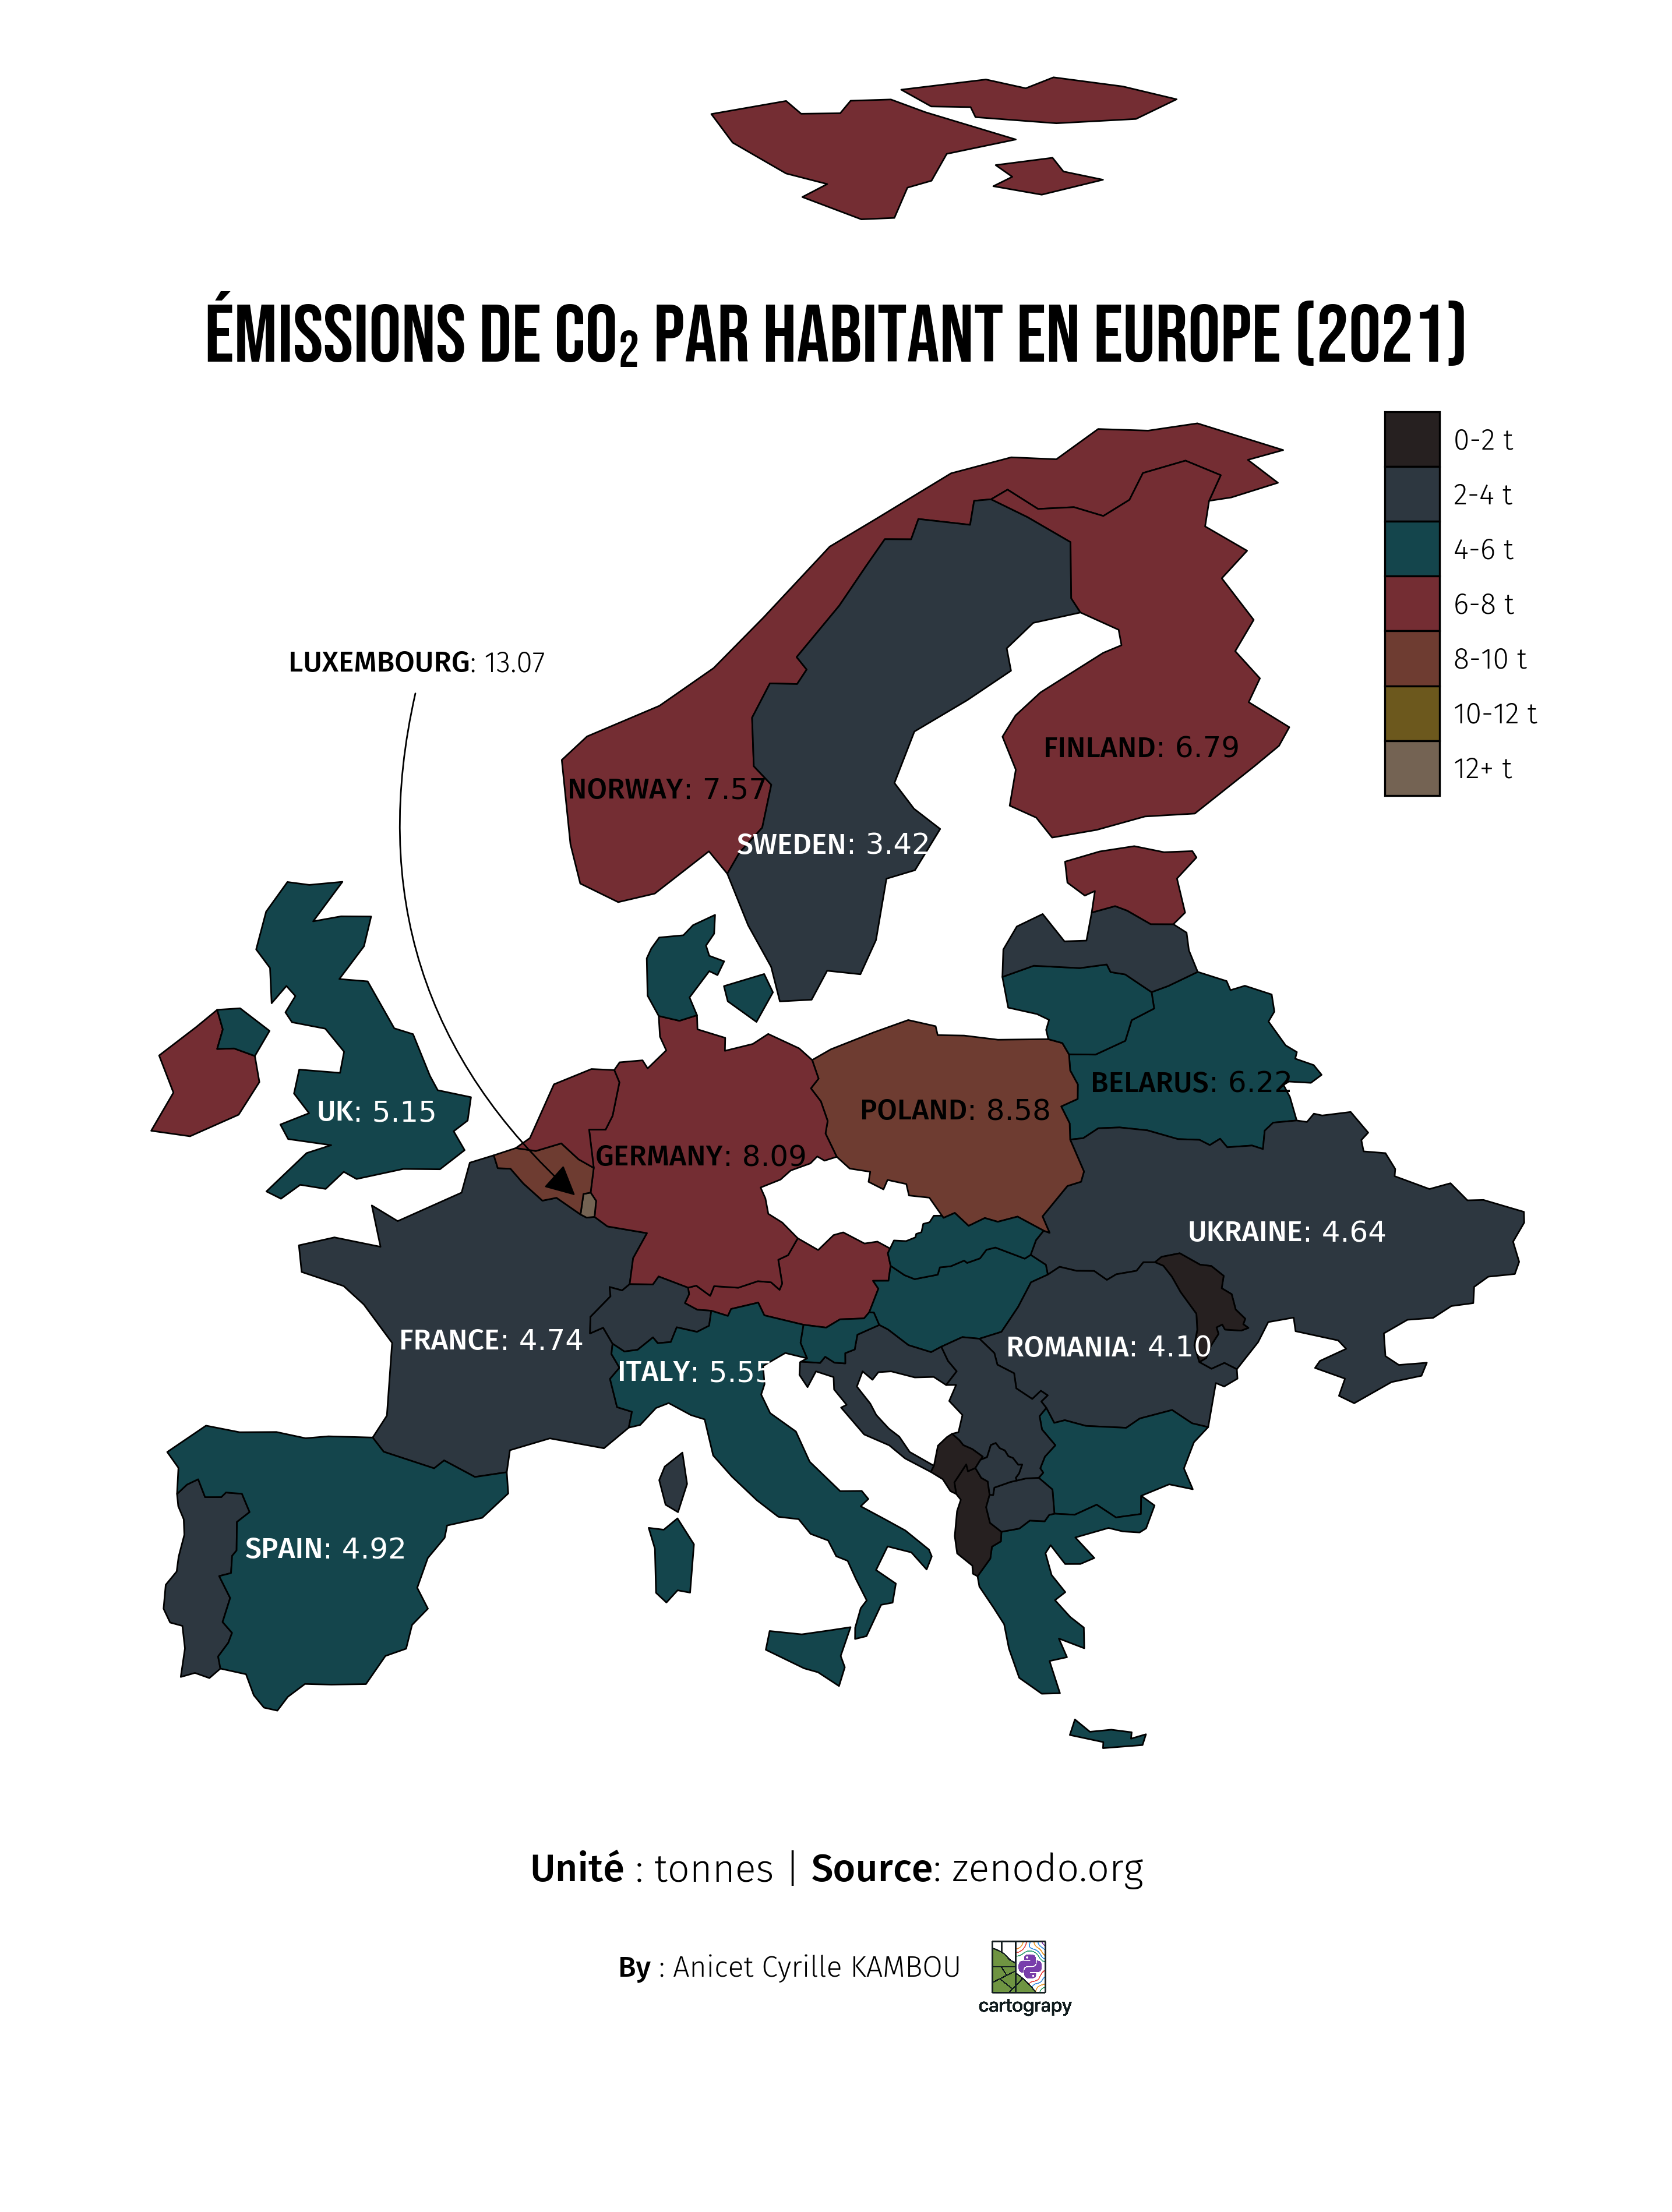

In [2]:
import pandas as pd
import cartograpy as cp

# 1. DONNÉES
world = cp.load(
    "https://raw.githubusercontent.com/holtzy/the-python-graph-gallery/master/static/data/europe.geojson"
)
df = cp.load(
    "https://raw.githubusercontent.com/holtzy/the-python-graph-gallery/master/static/data/co2PerCapita.csv"
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

## Fusion des données
data = world.merge(df, how="left", left_on="name", right_on="Country")

## Filtrage des données pour l'Europe, en excluant la Russie et l'Islande, et en ne gardant que l'année 2021
data = data.query('continent == "Europe" and name not in ["Russia", "Iceland"] and Year == 2021')
data = data[["name", "Total", "geometry"]].dropna(subset=["Total", "geometry"]).copy()

proj = data.to_crs(epsg=3035)
data["centroid"] = proj.geometry.centroid.to_crs(data.crs)

my_cmap = "PonyoDark"
# 2. POLICES
font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")

text_color = "black"
background_color = "white"

# 3. CARTE
m = cp.Map(figsize=(10, 10), dpi=400, basemap=False, title="")
m.set_background_color(background_color)
m.add_polygons_choropleth(
    data,
    column_to_plot="Total",
    cmap=my_cmap,
    edge_color="black",
    linewidth=0.5,
    show_labels=True,
    show_colorbar=False,
)
m.set_extent([-11, 32, 41, 73])
m.hide_gridline()
# m.add_basemap()

# 4. ANNOTATIONS PAR PAYS (nom en gras inline via add_custom_text)
adjustments = {
    "France": (10, 3), "Italy": (-2.4, 2.5), "Finland": (0, -2),
    "Belarus": (0, -0.4), "Ireland": (0, -1), "Germany": (-0.2, 0),
    "Poland": (0, 0.2), "Sweden": (-1.2, -2.8),
    "United Kingdom": (1, -1.5), "Norway": (-4, -5.5),
}
countries_to_annotate = [
    "France", "Italy", "Romania", "Poland", "Finland", "Ukraine",
    "Spain", "Germany", "Sweden", "United Kingdom", "Belarus", "Norway",
]

data_by_country = data.set_index("name")

for country in countries_to_annotate:
    if country not in data_by_country.index:
        continue
    row = data_by_country.loc[country]
    dx, dy = adjustments.get(country, (0, 0))
    x, y = row["centroid"].x + dx, row["centroid"].y + dy
    rate = row["Total"]
    label = "UK" if country == "United Kingdom" else country

    m.add_custom_text(
        f"<{label.upper()}>: {rate:.2f}", (x, y), to="ax",
        fontsize=9, color="white" if rate < 6 else text_color,
        ha="center", va="center",
        highlight_textprops=[{"font": font_bold}],
    )


# 5. LUXEMBOURG (add_fig_arrow + add_custom_text, en coords figure 0-1)
lux = data[data["name"] == "Luxembourg"]
if not lux.empty:
    lux_value = lux.iloc[0]["Total"]

    m.add_fig_arrow(
        tail_position=(0.32, 0.70),
        head_position=(0.39, 0.48),
        radius=0.3,
        width=0.5, head_width=4, head_length=8, color="black",
    )
    m.add_custom_text(
        f"<LUXEMBOURG>: {lux_value:.2f}", (0.32, 0.71), to="fig",
        highlight_textprops=[{"font": font_bold}],
        color=text_color, fontsize=9, font=font_text,
        ha="center", va="center",
    )

# 6. LÉGENDE PAR CLASSES
value_ranges = [0, 2, 4, 6, 8, 10, 12, 15]
labels = ["0-2 t", "2-4 t", "4-6 t", "6-8 t", "8-10 t", "10-12 t", "12+ t"]
cmap_obj = cp.load_cmap(my_cmap)

items = [
    (lab, cmap_obj((value_ranges[i] + value_ranges[i + 1]) / 2 / value_ranges[-1]))
    for i, lab in enumerate(labels)
]
m.add_swatch_legend(
    items, xy=(35, 70),
    rect_width=2, 
    rect_height=1.5, y_step=1.5,
    fontsize=9, color=text_color,
    edge_color="black", linewidth=0.6,
    font=font_text,
)

# 7. TITRE / SOUS-TITRE
m.add_custom_text(
    "Émissions de CO₂ par habitant en Europe (2021)", (0.5, 0.87), to="fig",
    color=text_color, fontsize=25, font=font_title,
    ha="center", va="top",
)
m.add_custom_text(
    "<Unité> : tonnes | <Source>: zenodo.org", (0.5, 0.2), to="fig",
    color=text_color, fontsize=12, font=font_text,
    ha="center", va="top",
    highlight_textprops=[{"font": font_bold}, {"font": font_bold}],
)

m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.48, 0.15), to="fig",
    color=text_color, fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

# m.add_north_arrow(to="fig", shadow=False,scale=0.3, label=" ",position=(0.3, 0.85))

m.add_image("logo.png", (0.44, 0.1), zoom=0.035) 

# m.add_background_image("bg_image.jpg", alpha=0.5, zoom=1)
# 8. EXPORT
# m.save("output_galerie/web-map-with-custom-legend.png", dpi=600)
m.show()

# Carte des régions de la Côte d'Ivoire

⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326


C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_13280\3407340299.py:18: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  m.add_layer(civ, facecolor="lightyellow", edgecolor="black")
c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:3348: DeprecationWarning: pathlib.Path.__enter__() is deprecated and scheduled for removal in Python 3.13; Path objects as a context manager is a no-op
  with importlib.resources.files("cartograpy").joinpath(
Can't handle color: param(outline)


🧭 Flèche du Nord ajoutée (SVG)
🔍 Carte de situation ajoutée (map-utils)
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.50
   Ratio données: 0.95
   Étendue: [-11.00, -0.08, 3.91, 11.19]


c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:5808: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout()
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Pr

Carte sauvegardée: output_galerie/carte_regions_cote_d_ivoire.png


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartogr

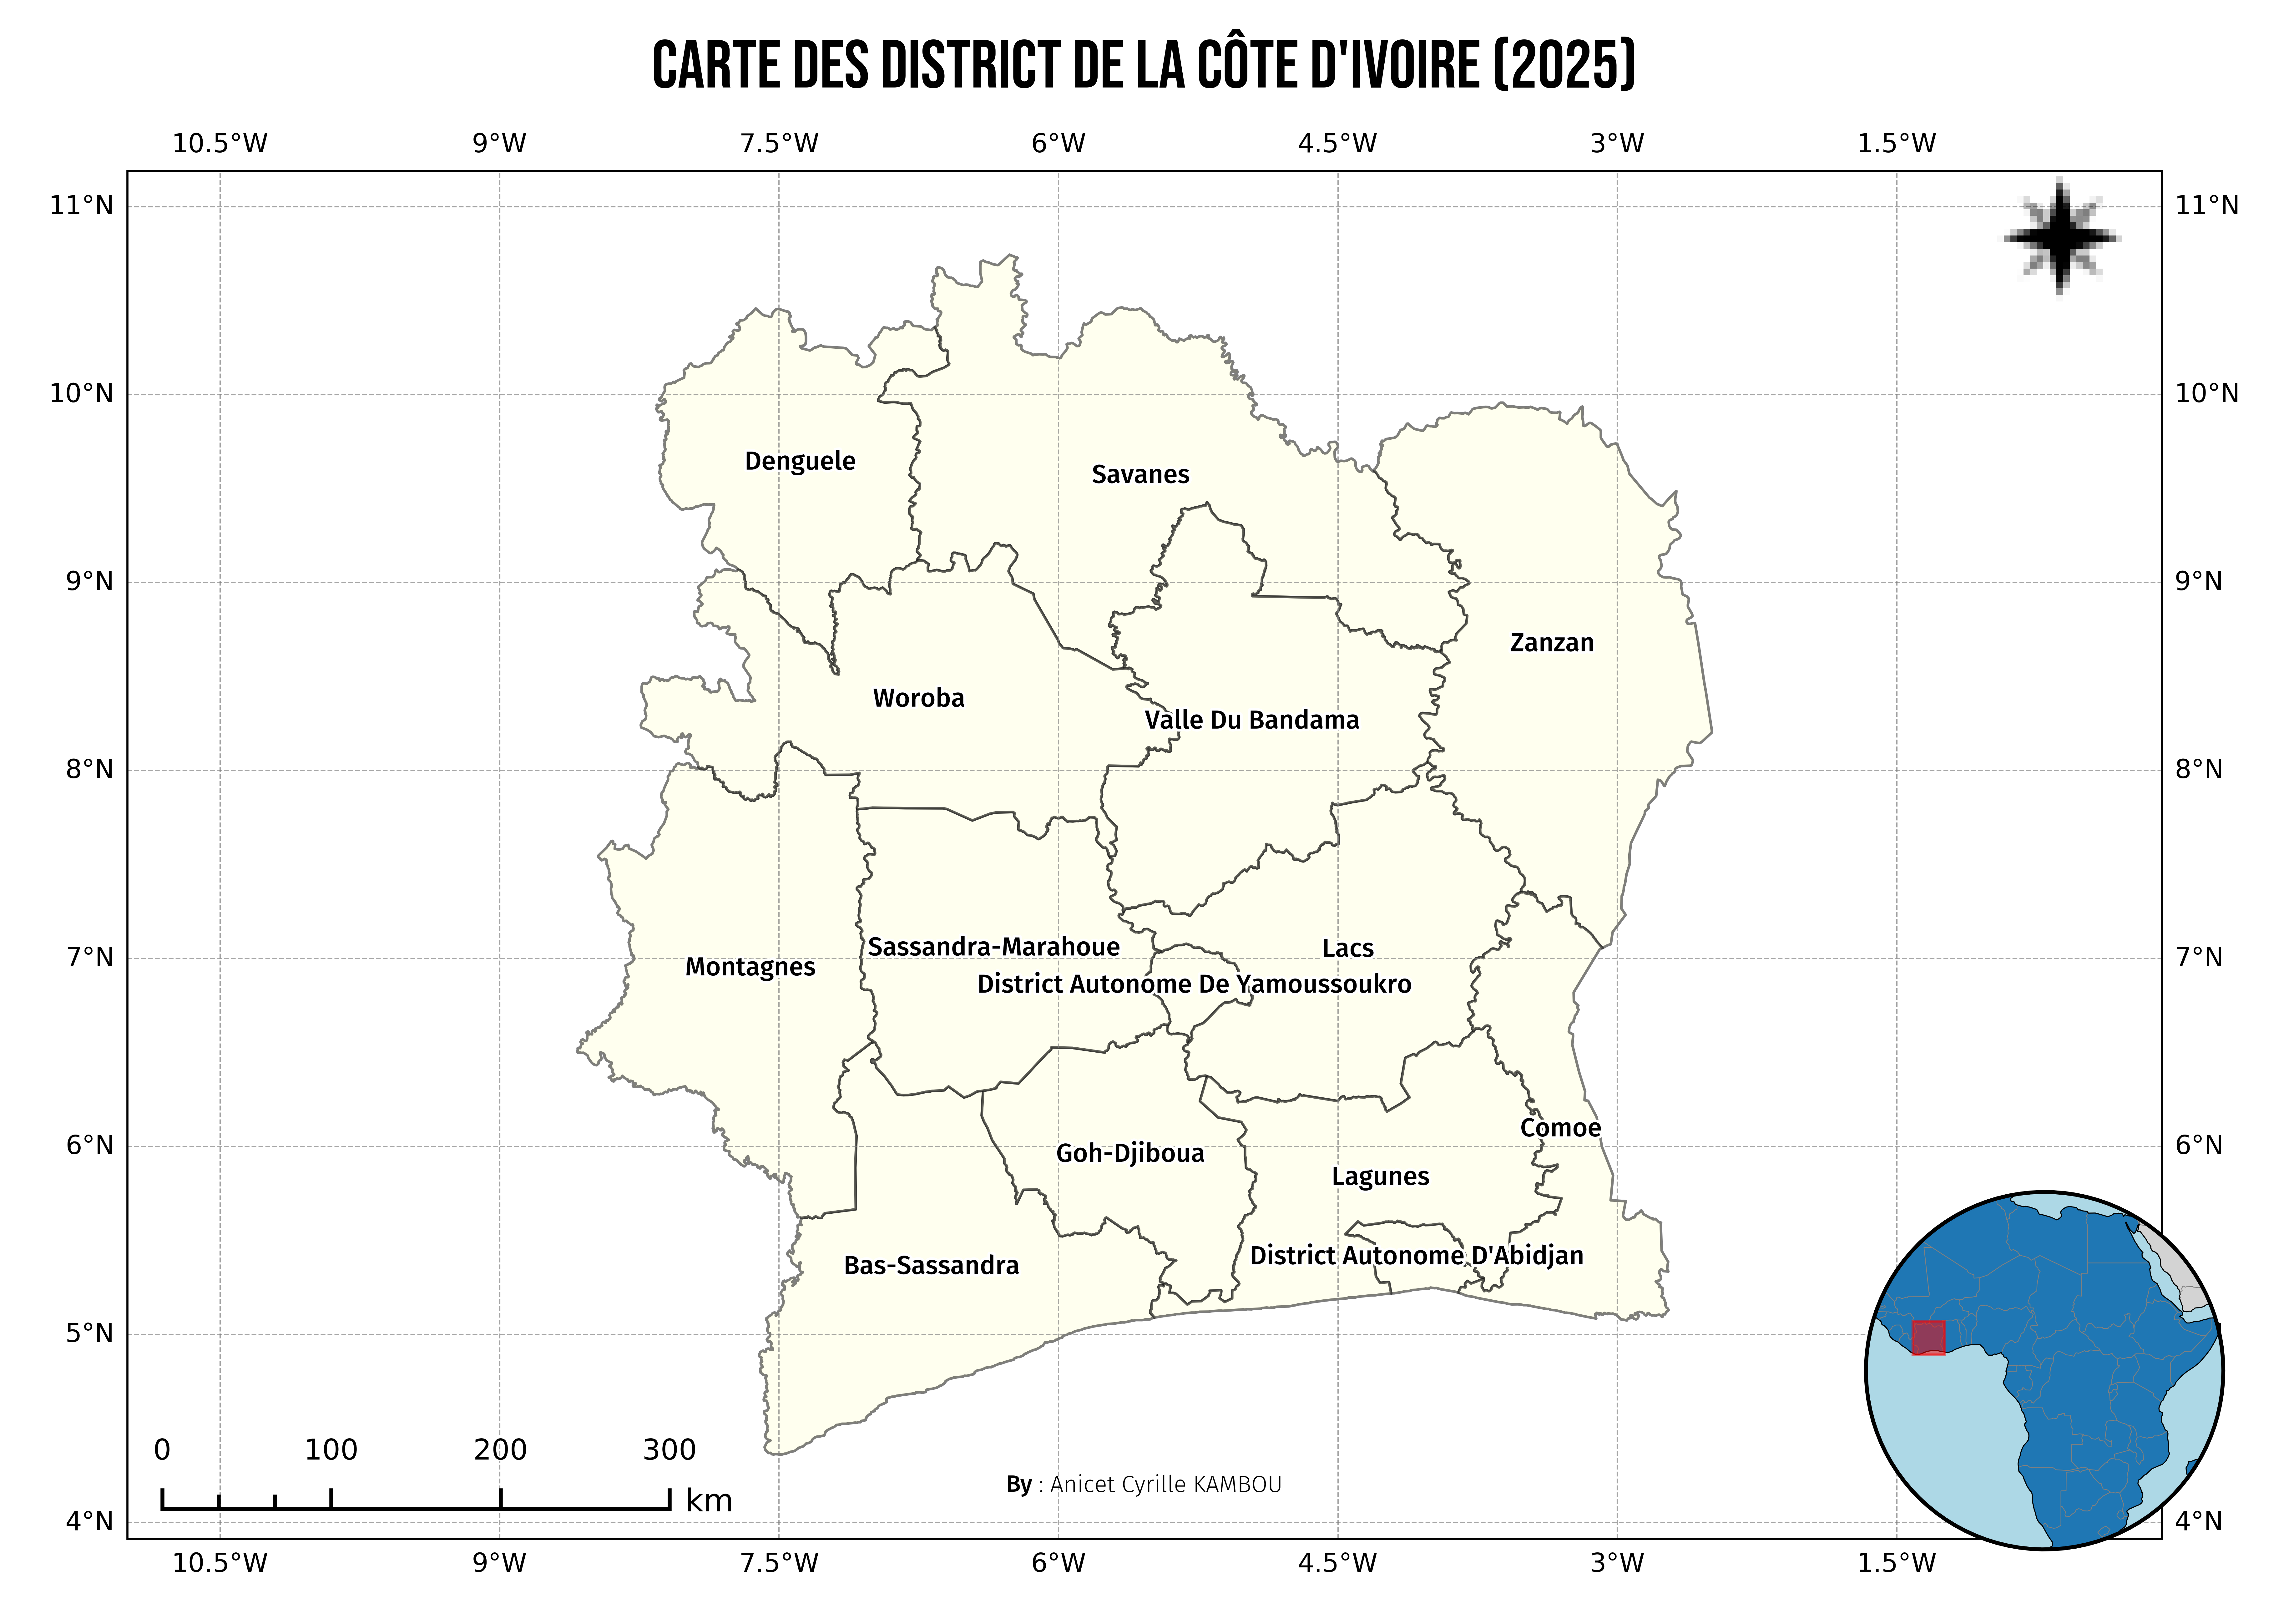

In [3]:
import cartograpy as cp
from cartograpy.data import Bound
from cartograpy.mapper import Map


my_cmap = "PonyoDark"
# 2. POLICES
font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")
font = cp.google_font("Fira Sans", weight="medium")

bound = Bound()
civ = bound.get_admin("CIV", adm=1)  # frontières nationales, via GeoBoundaries

m = Map(basemap=False,dpi=600)

m.add_layer(civ, facecolor="lightyellow", edgecolor="black")
m.add_north_arrow(style="svg",arrow=12, zoom=0.4, color="black")
m.add_gridlines()
# m.hide_gridline()
m.set_background_color("white")
m.add_scale_bar(style="ticks")
m.add_labels(civ, label_column="shapeName",font=font,color="black")
m.add_inset(data=civ, on=bound.get_continent("Africa"),zoom_to_on=True,box_color="black",box_linewidth=1,to="fig", circular=True, position=(0.7, 0.2))
m.add_custom_text(
    "carte des district de la Côte d'Ivoire (2025)", (0.5, 1.05), to="fig",
    color="black", fontsize=26, font=font_title,
    ha="center", va="top",
)
m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.50, 0.08), to="fig",
    color="black", fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

m.save("output_galerie/carte_regions_cote_d_ivoire.png", dpi=600)

# Carte de Employées, agriculture, femmes (% d’emploi des femmes)

📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 0.95
   Étendue: [-24.38, 57.89, -39.87, 42.40]


C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_13280\1974754764.py:68: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid  # calculé une fois, réutilisé pour chaque étiquette


🖼️ Image ajoutée
🧭 Flèche du Nord ajoutée (map-utils)
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 0.95
   Étendue: [-24.38, 57.89, -39.87, 42.40]


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


Carte sauvegardée: output_galerie/emploi_agricole_femmes_2025_afrique.png


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartogr

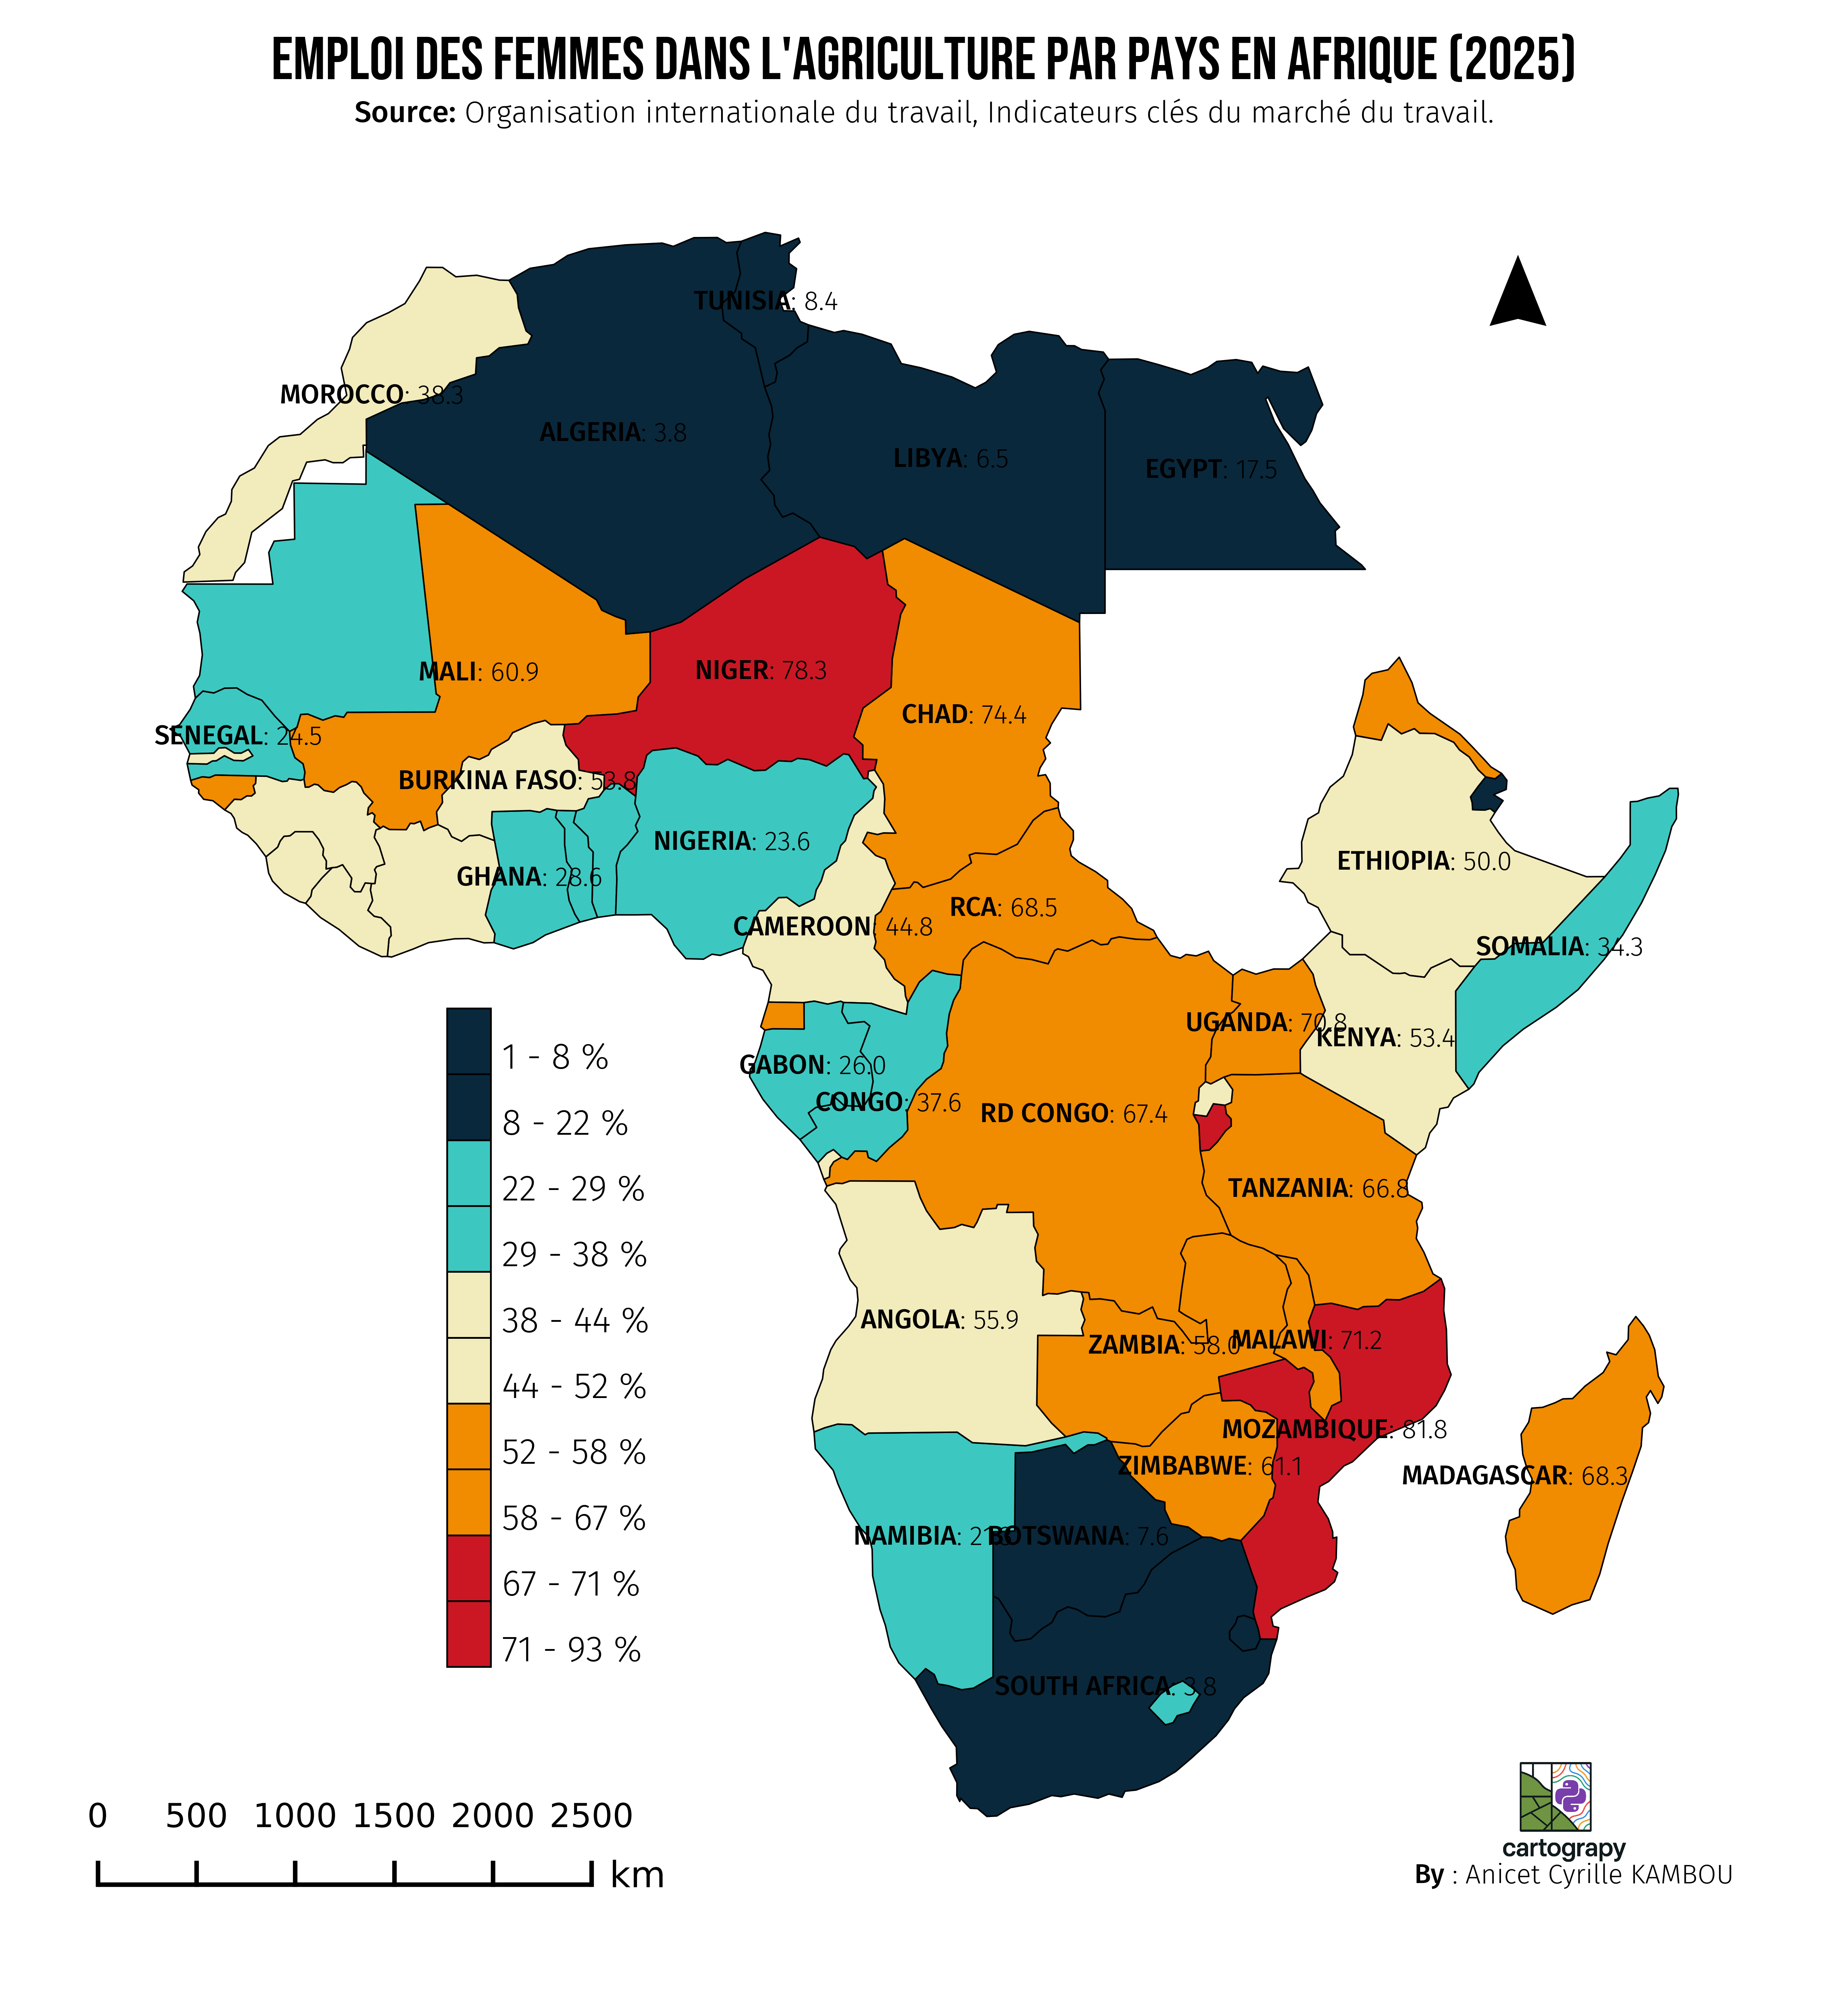

In [4]:
import cartograpy as cp
from cartograpy.data import WorldBank, Bound
import wbdata
import matplotlib.cm as cm
import numpy as np
from cartograpy.styling import load_cmap

my_cmap = "atomic_clock"
cmap = load_cmap(my_cmap)

font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")
text_color="black"
wb = WorldBank()
bound = Bound()

INDICATOR = "SL.AGR.EMPL.FE.ZS"  # Employées, agriculture, femmes (% d'emploi des femmes)

# 1. Récupérer l'indicateur pour 2025
df = wb.get_data({INDICATOR: "valeur"}, country="all", date="2025")
df = df.reset_index()  # colonnes : country, valeur

# 2. Correspondance nom de pays -> ISO3 (exclut les agrégats régionaux)
countries_meta = wbdata.get_countries()
name_to_iso3 = {
    c["name"]: c["id"]
    for c in countries_meta
    if c["region"]["value"] != "Aggregates"
}
df["iso3"] = df["country"].map(name_to_iso3)
df = df.dropna(subset=["iso3", "valeur"])

# 3. Frontières — uniquement les pays d'Afrique
world = bound.get_world("country")  # colonnes : name, iso3, continent, geometry
africa = world[world["continent"] == "Africa"]

# 4. Fusion géométries + valeurs
gdf = africa.merge(df[["iso3", "valeur"]], on="iso3", how="inner")

# 5. Carte
m = cp.Map(figsize=(10, 10), title="", dpi=600, basemap=False)
m.add_polygons_choropleth(
    gdf,
    column_to_plot="valeur",
    cmap=my_cmap,
    show_colorbar=False,
)
# m.add_gridlines()
# --- Légende à rectangles (bins de quantiles) ---------------------------
n_bins = 10
bin_edges = np.quantile(gdf["valeur"], np.linspace(0, 1, n_bins + 1))
items = [
    (f"{bin_edges[i]:.0f} - {bin_edges[i+1]:.0f} %", cmap(i / (n_bins - 1)))
    for i in range(n_bins)
]

m.add_swatch_legend(
    items, xy=(-5, -1),
    rect_width=2,
    rect_height=3, y_step=3,
    fontsize=12, color=text_color,
    edge_color="black", linewidth=0.6,
    font=font_text,
)

# --- Étiquettes de pays -------------------------------------------------
gdf["centroid"] = gdf.geometry.centroid  # calculé une fois, réutilisé pour chaque étiquette

countries_to_annotate = [
    "Algeria", "Libya", "Tunisia", "Morocco", "Egypt",
    "Nigeria", "Ghana", "Senegal", "Mali", "Niger", "Burkina Faso",
    "Cameroon", "Chad", "Dem. Rep. Congo", "Congo", "Gabon", "Central African Rep.",
    "Ethiopia", "Kenya", "Tanzania", "Uganda", "Somalia", "S. Sudan", "Sudan",
    "South Africa", "Zambia", "Zimbabwe", "Mozambique", "Namibia", "Botswana", "Angola",
    "Madagascar", "Malawi",
]  # noms Natural Earth, pas les noms World Bank — abrégés pour certains pays
abbreviations = {"Dem. Rep. Congo": "RD Congo", "Central African Rep.": "RCA"}
adjustments = {
    "Madagascar": (-3, 0),   # décale l'étiquette pour éviter qu'elle sorte du cadre
    "Congo": (0, -1.5),      # évite le chevauchement avec "RD Congo", juste à côté
}

text_color = "black"
rate_threshold = 0  # au-delà, le fond est jugé assez sombre pour du texte blanc

data_by_country = gdf.set_index("name")

for country in countries_to_annotate:
    if country not in data_by_country.index:
        continue
    row = data_by_country.loc[country]
    dx, dy = adjustments.get(country, (0, 0))
    x, y = row["centroid"].x + dx, row["centroid"].y + dy
    rate = row["valeur"]
    label = abbreviations.get(country, country)

    m.add_custom_text(
        f"<{label.upper()}>: {rate:.1f}", (x, y), to="ax",
        fontsize=9, color="white" if rate < rate_threshold else text_color,
        ha="center", va="center", font=font_text,
        highlight_textprops=[{"font": font_bold}],
    )


m.add_custom_text(
    "Emploi des femmes dans l'agriculture par pays en Afrique (2025)",
    (0.5, 0.95), to="fig", fontsize=20, fontweight="bold", ha="center",font=font_title
)

m.add_custom_text(
    "<Source:> Organisation internationale du travail, Indicateurs clés du marché du travail.",
    (0.5, 0.92), to="fig", fontsize=10, ha="center",font=font_text,
    highlight_textprops=[{"font": font_bold}]
)

m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.8, 0.1), to="fig",
    color="black", fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

m.add_image("logo.png", (0.722, 0.09), zoom=0.05) 
# m.add_image("bg_image.jpg", (0.5, 0.5), zoom=0.1, zorder=-1, alpha=0.5) 
m.hide_gridline()
# m.add_north_arrow()
m.add_north_arrow(to="fig", shadow=False,scale=0.3, label=" ",position=(0.8, 0.86))
m.add_scale_bar(style="ticks", to="fig", position=(0.1, 0.08))


m.save("output_galerie/emploi_agricole_femmes_2025_afrique.png")


# Données de la banque mondiale

In [5]:
import cartograpy as cp


wb=cp.WorldBank()

wb.get_sources()

  id  name
----  --------------------------------------------------------------------
   1  Doing Business
   2  World Development Indicators
   3  Worldwide Governance Indicators
   5  Subnational Malnutrition Database
   6  International Debt Statistics
  11  Africa Development Indicators
  12  Education Statistics
  13  Enterprise Surveys
  14  Gender Statistics
  15  Global Economic Monitor
  16  Health Nutrition and Population Statistics
  18  IDA Results Measurement System
  19  Millennium Development Goals
  20  Quarterly Public Sector Debt
  22  Quarterly External Debt Statistics SDDS
  23  Quarterly External Debt Statistics GDDS
  25  Jobs
  27  Global Economic Prospects
  28  Global Findex database
  29  The Atlas of Social Protection: Indicators of Resilience and Equity
  30  Exporter Dynamics Database – Indicators at Country-Year Level
  31  Country Policy and Institutional Assessment
  32  Global Financial Development
  33  G20 Financial Inclusion Indicators
  34  Global P

In [6]:
wb.get_indicators(source=63)

id                 name
-----------------  ----------------------------------------------------------
HD.HCI.AMRT        Survival Rate from Age 15-60
HD.HCI.AMRT.FE     Survival Rate from Age 15-60, Female
HD.HCI.AMRT.MA     Survival Rate from Age 15-60, Male
HD.HCI.EYRS        Expected Years of School
HD.HCI.EYRS.FE     Expected Years of School, Female
HD.HCI.EYRS.MA     Expected Years of School, Male
HD.HCI.HLOS        Harmonized Test Scores
HD.HCI.HLOS.FE     Harmonized Test Scores, Female
HD.HCI.HLOS.MA     Harmonized Test Scores, Male
HD.HCI.LAYS        Learning-Adjusted Years of School
HD.HCI.LAYS.FE     Learning-Adjusted Years of School, Female
HD.HCI.LAYS.MA     Learning-Adjusted Years of School, Male
HD.HCI.MORT        Probability of Survival to Age 5
HD.HCI.MORT.FE     Probability of Survival to Age 5, Female
HD.HCI.MORT.MA     Probability of Survival to Age 5, Male
HD.HCI.OVRL        Human Capital Index (HCI) (scale 0-1)
HD.HCI.OVRL.FE     Human Capital Index (HCI), Female (

In [7]:
wb.get_countries(query="Africa")

id    name
----  --------------------------------------------------------------------------------
AFE   Africa Eastern and Southern
AFR   Africa
AFW   Africa Western and Central
BMN   Middle East, North Africa, Afghanistan & Pakistan (IBRD only)
BSS   Sub-Saharan Africa (IBRD-only countries)
CAA   Sub-Saharan Africa (IFC classification)
CAF   Central African Republic
CME   Middle East and North Africa (IFC classification)
DMN   Middle East, North Africa, Afghanistan & Pakistan (IDA total)
DNS   IDA countries in Sub-Saharan Africa not classified as fragile situations
DSF   IDA countries in Sub-Saharan Africa classified as fragile situations
DSS   Sub-Saharan Africa (IDA-eligible countries)
FXS   IDA countries classified as fragile situations, excluding Sub-Saharan Africa
MEA   Middle East, North Africa, Afghanistan & Pakistan
MNA   Middle East, North Africa, Afghanistan & Pakistan (excluding high income)
NAF   North Africa
NRS   Non-resource rich Sub-Saharan Africa countries
NXS   IDA c

In [8]:
idh=wb.get_data({"HD.HCI.OVRL": "IDH"}, country="all")


In [9]:
idh.dropna(subset=["IDH"], inplace=True)

In [10]:
idh.head()


IDH
country     date          
Afghanistan 2020  0.400284
            2018  0.393489
            2017  0.389000
Albania     2020  0.634251
            2018  0.628666

In [11]:
import cartograpy as cp
bd=cp.Bound()
bd.get_admin("CIV", adm=1)  # frontières nationales, via GeoBoundaries

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"POLYGON ((-6.4045 6.29712, -6.41745 6.29508, -...",Bas-Sassandra,,83157122B96959932745266,CIV,ADM1
1,"POLYGON ((-6.6648 10.35941, -6.66875 10.3549, ...",Denguele,,83157122B12160353323799,CIV,ADM1
2,"POLYGON ((-3.71635 5.29744, -3.71732 5.30084, ...",District Autonome D'Abidjan,,83157122B76853064397847,CIV,ADM1
3,"POLYGON ((-5.3043 6.5512, -5.29381 6.55779, -5...",District Autonome De Yamoussoukro,,83157122B30232425959699,CIV,ADM1
4,"POLYGON ((-5.43268 5.26612, -5.43269 5.26884, ...",Goh-Djiboua,,83157122B34711482467037,CIV,ADM1
5,"POLYGON ((-5.3043 6.5512, -5.30411 6.54802, -5...",Lacs,,83157122B20352934117266,CIV,ADM1
6,"POLYGON ((-7.00001 6.55631, -6.99677 6.56222, ...",Montagnes,,83157122B69310198422077,CIV,ADM1
7,"POLYGON ((-6.4045 6.29712, -6.369 6.30238, -6....",Sassandra-Marahoue,,83157122B74959515955757,CIV,ADM1
8,"POLYGON ((-6.75671 9.11732, -6.754 9.11879, -6...",Savanes,,83157122B28791092437733,CIV,ADM1
9,"POLYGON ((-4.01818 8.04803, -4.01611 8.06285, ...",Valle Du Bandama,,83157122B62906982633778,CIV,ADM1


In [12]:
import wbdata
import cartograpy as cp
from cartograpy.data import WorldBank, Bound
from cartograpy.mapper import Map

wb = WorldBank()
bound = Bound()

# --- Données IDH (Banque mondiale) --------------------------------------
idh = wb.get_data({"HD.HCI.OVRL": "IDH"}, country="all")
idh = idh.reset_index().dropna(subset=["IDH"])
idh = idh.sort_values("date", ascending=False).groupby("country", as_index=False).first()

# --- ISO3 pour pouvoir joindre avec la géométrie -------------------------
countries_meta = wbdata.get_countries()
name_to_iso3 = {
    c["name"]: c["id"]
    for c in countries_meta
    if c["region"]["value"] != "Aggregates"
}
idh["iso3"] = idh["country"].map(name_to_iso3)
idh = idh.dropna(subset=["iso3"])

# --- Limites de l'Afrique de l'Ouest -------------------------------------
WEST_AFRICA_ISO3 = [
    "BEN", "BFA", "CPV", "CIV", "GMB", "GHA", "GIN", "GNB",
    "LBR", "MLI", "MRT", "NER", "NGA", "SEN", "SLE", "TGO",
]
world = bound.get_world("country")
west_africa = world[world["iso3"].isin(WEST_AFRICA_ISO3)]
gdf = west_africa.merge(idh[["iso3", "IDH"]], on="iso3", how="left")


In [13]:
font_labels = cp.google_font("Caveat", weight="regular")
font_title = cp.google_font("Caveat", weight="bold")
cp.set_style("science", source="SciencePlots")
cp.list_all_styles()

✅ Style SciencePlots appliqué : science


{'matplotlib': ['Solarize_Light2',
  '_classic_test_patch',
  '_mpl-gallery',
  '_mpl-gallery-nogrid',
  'bmh',
  'bright',
  'cjk-jp-font',
  'cjk-kr-font',
  'cjk-sc-font',
  'cjk-tc-font',
  'classic',
  'dark_background',
  'discrete-rainbow-1',
  'discrete-rainbow-10',
  'discrete-rainbow-11',
  'discrete-rainbow-12',
  'discrete-rainbow-13',
  'discrete-rainbow-14',
  'discrete-rainbow-15',
  'discrete-rainbow-16',
  'discrete-rainbow-17',
  'discrete-rainbow-18',
  'discrete-rainbow-19',
  'discrete-rainbow-2',
  'discrete-rainbow-20',
  'discrete-rainbow-21',
  'discrete-rainbow-22',
  'discrete-rainbow-23',
  'discrete-rainbow-3',
  'discrete-rainbow-4',
  'discrete-rainbow-5',
  'discrete-rainbow-6',
  'discrete-rainbow-7',
  'discrete-rainbow-8',
  'discrete-rainbow-9',
  'fast',
  'fivethirtyeight',
  'ggplot',
  'grayscale',
  'grid',
  'high-contrast',
  'high-vis',
  'ieee',
  'latex-sans',
  'light',
  'muted',
  'nature',
  'no-latex',
  'notebook',
  'petroff10',
  'p

📄 Format de papier: A4 (landscape) - Dimensions: 297 x 210 mm - Figure: 11.7" x 8.3"
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 1.45
   Étendue: [-20.31, 18.59, 2.07, 29.57]
🧭 Flèche du Nord ajoutée (map-utils)
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 1.45
   Étendue: [-20.31, 18.59, 2.07, 29.57]


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


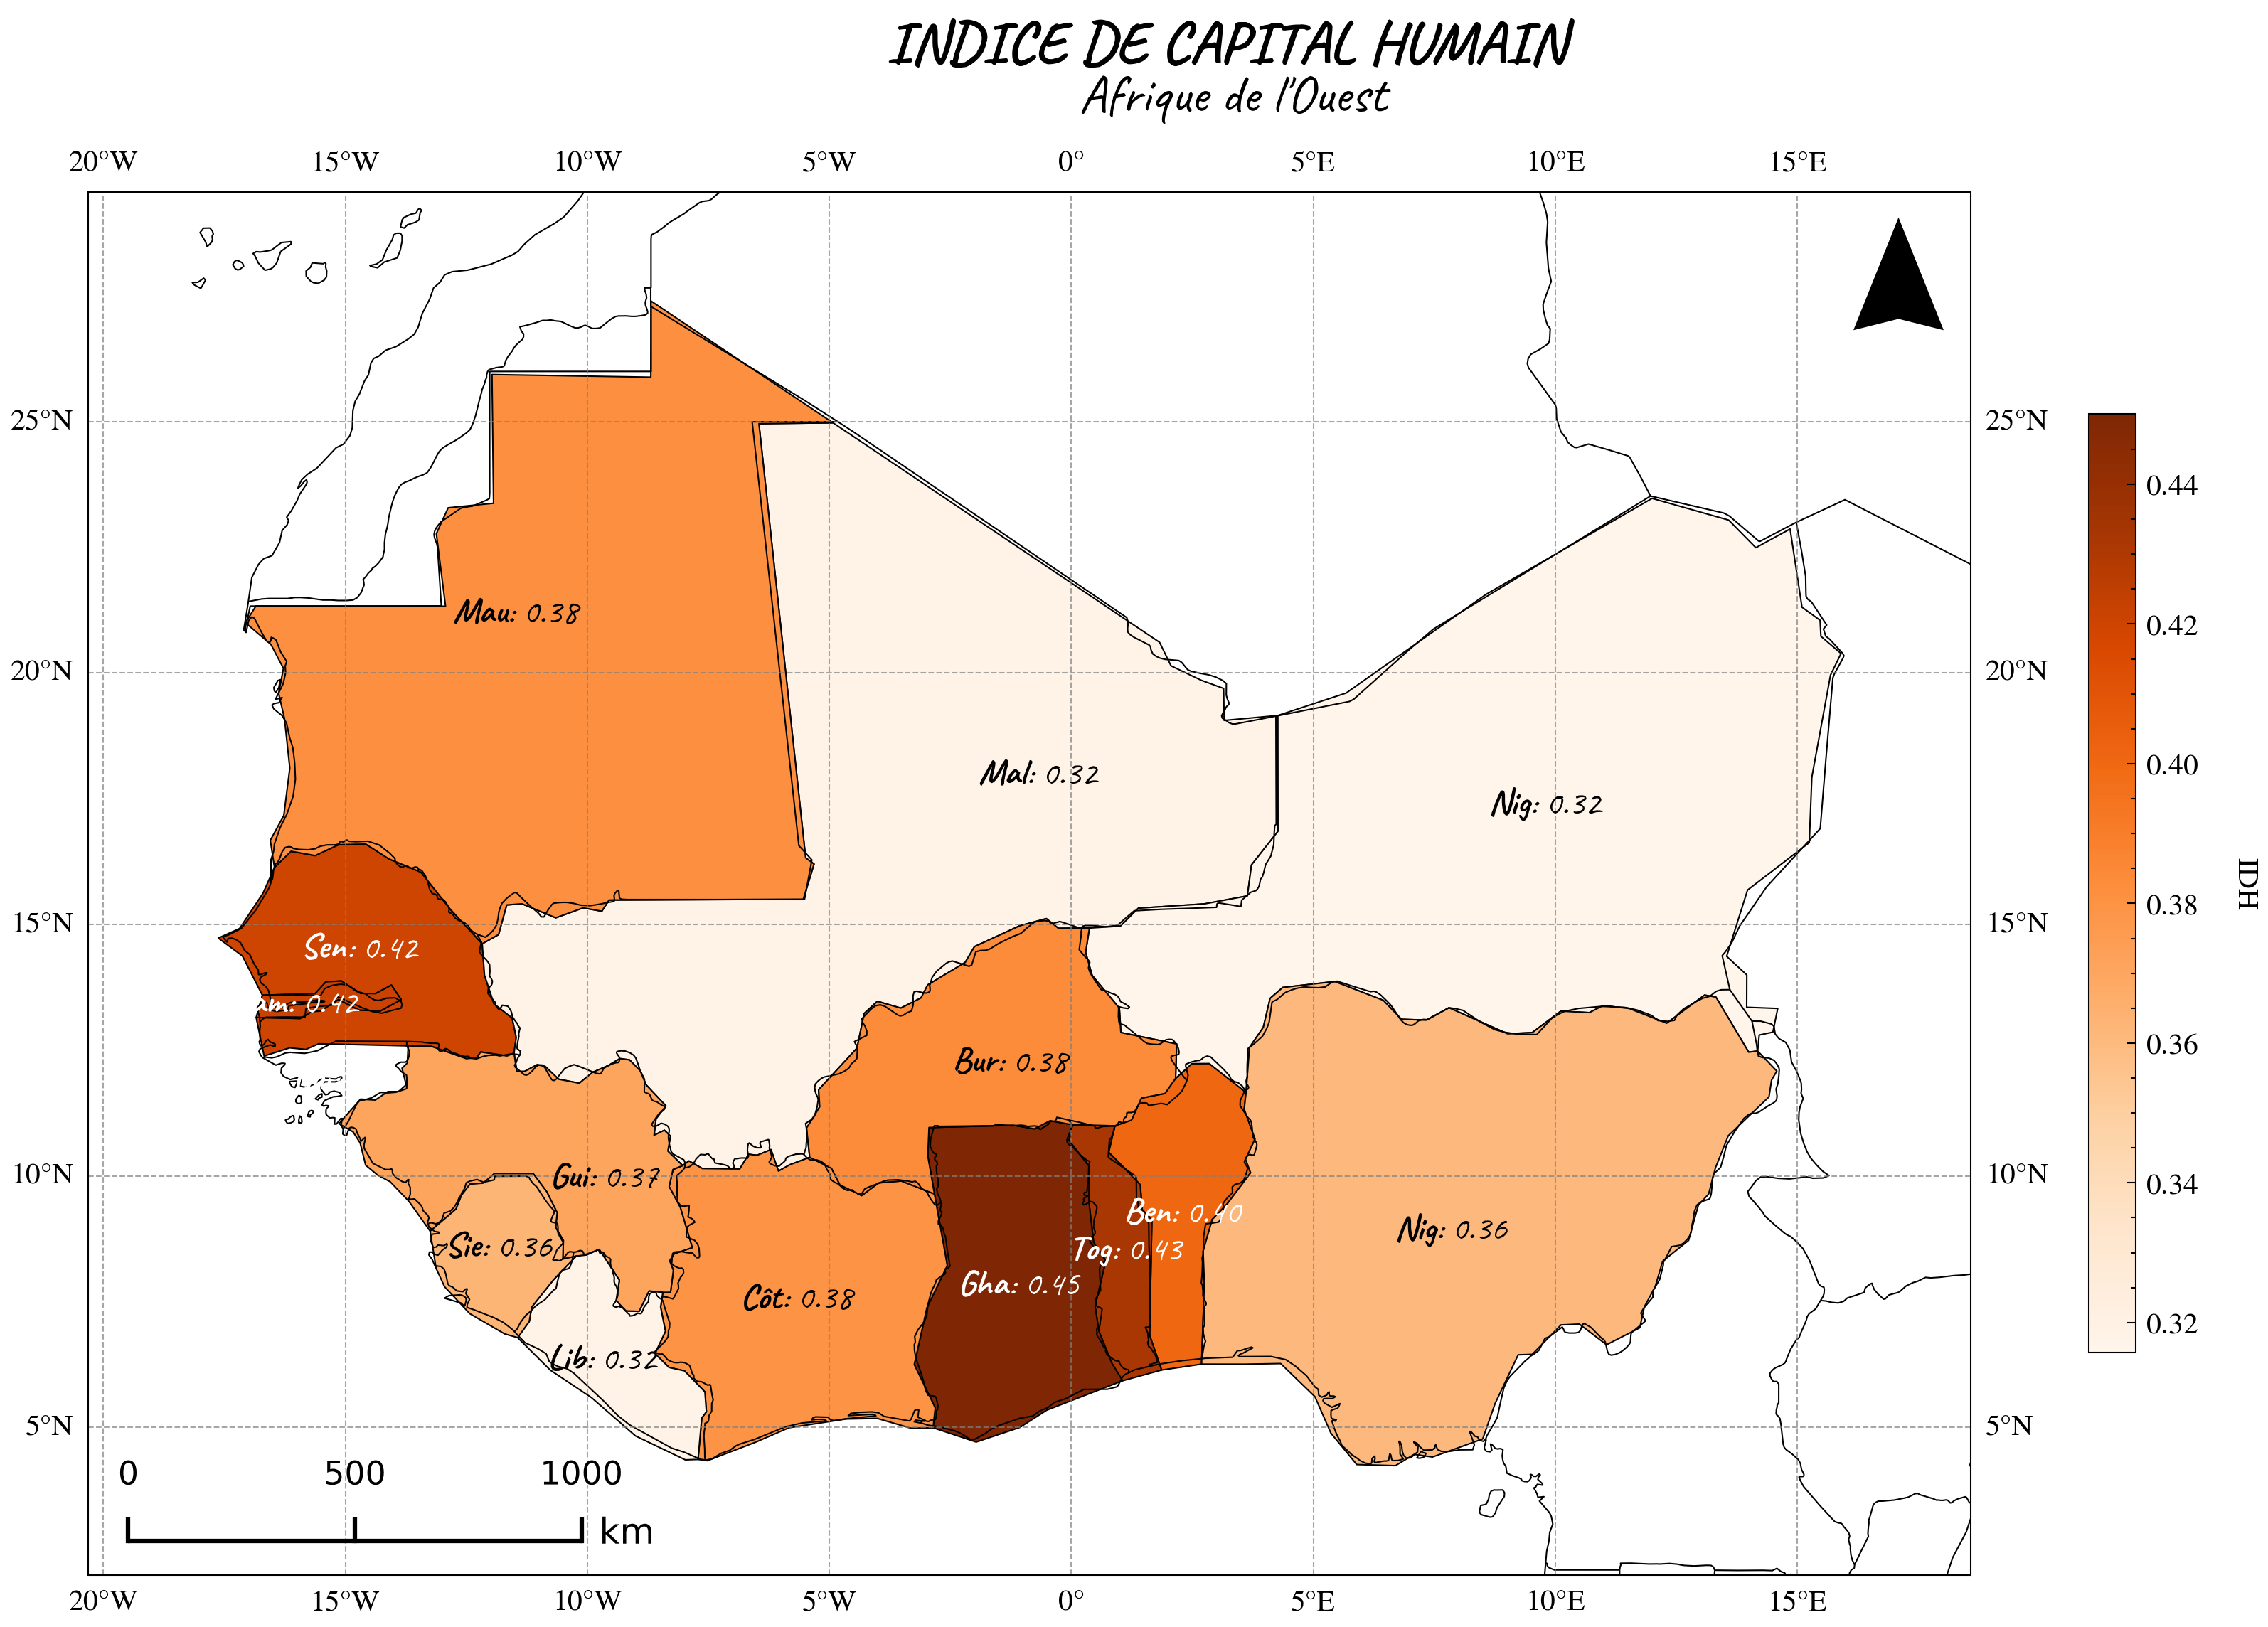

📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 1.45
   Étendue: [-20.31, 18.59, 2.07, 29.57]


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


Carte sauvegardée: output_galerie/idh_afrique_ouest.png


In [14]:
cmap="Oranges"
# --- Carte -----------------------------------------------------------------
m = Map(figsize="A4", title=" ")
m.add_polygons_choropleth(gdf, column_to_plot="IDH", title="IDH", cmap=cmap)

# --- Étiquettes de tous les pays
for _, row in gdf.iterrows():
    point = row.geometry.representative_point()
    m.add_custom_text(
        f"<{ row['name'][0:3] }>: { row['IDH']:.2f}",
        (point.x, point.y),
        to="ax",
        fontsize=12,
        color="black" if row["IDH"] < 0.4 else "white",
        ha="center",
        va="center",
        font=font_labels,
        highlight_textprops=[{"font": font_title}]
        # path_effects=[patheffects.withStroke(linewidth=2, foreground="white")],
    )

# --- Flèche de mise en avant sur la Côte d'Ivoire
civ_point = gdf.loc[gdf["iso3"] == "CIV", "geometry"].iloc[0].representative_point()


m.fig.canvas.draw()  # force le layout avant de convertir coords carte -> coords figure
head_x, head_y = m.ax.transData.transform((civ_point.x, civ_point.y))
head_position = tuple(m.fig.transFigure.inverted().transform((head_x, head_y)))
tail_position = (0.15, 0.23)

# m.add_fig_arrow(
#     tail_position=tail_position,
#     head_position=head_position,
#     radius=0.3,
#     width=0.5, head_width=4, head_length=8, color="black",
# )
# m.add_custom_text(
#     f"<CÔTE D'IVOIRE>: {civ_row['IDH']:.2f}", (tail_position[0], tail_position[1] + 0.02), to="fig",
#     highlight_textprops=[{"font": font_bold}],
#     color="black", fontsize=9, font=font_labels,
#     ha="center", va="center",
# )

m.add_custom_text(
    "INDICE DE CAPITAL HUMAIN",
    (0.5, 0.95), to="fig", fontsize=20, fontweight="bold", ha="center",font=font_title
)
m.add_custom_text(
    " Afrique de l'Ouest",
    (0.5, 0.92), to="fig", fontsize=18, ha="center",font=font_labels
)
m.add_gridlines()
m.add_north_arrow(label=" ")
m.add_scale_bar(style="ticks")
m.show()
m.save("output_galerie/idh_afrique_ouest.png", dpi=600)


📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.45
   Étendue: [-19.97, 18.25, -3.29, 34.93]
🧭 Flèche du Nord ajoutée (map-utils)
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.45
   Étendue: [-19.97, 18.25, -3.29, 34.93]


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


Carte sauvegardée: carte_idh.png


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartogr

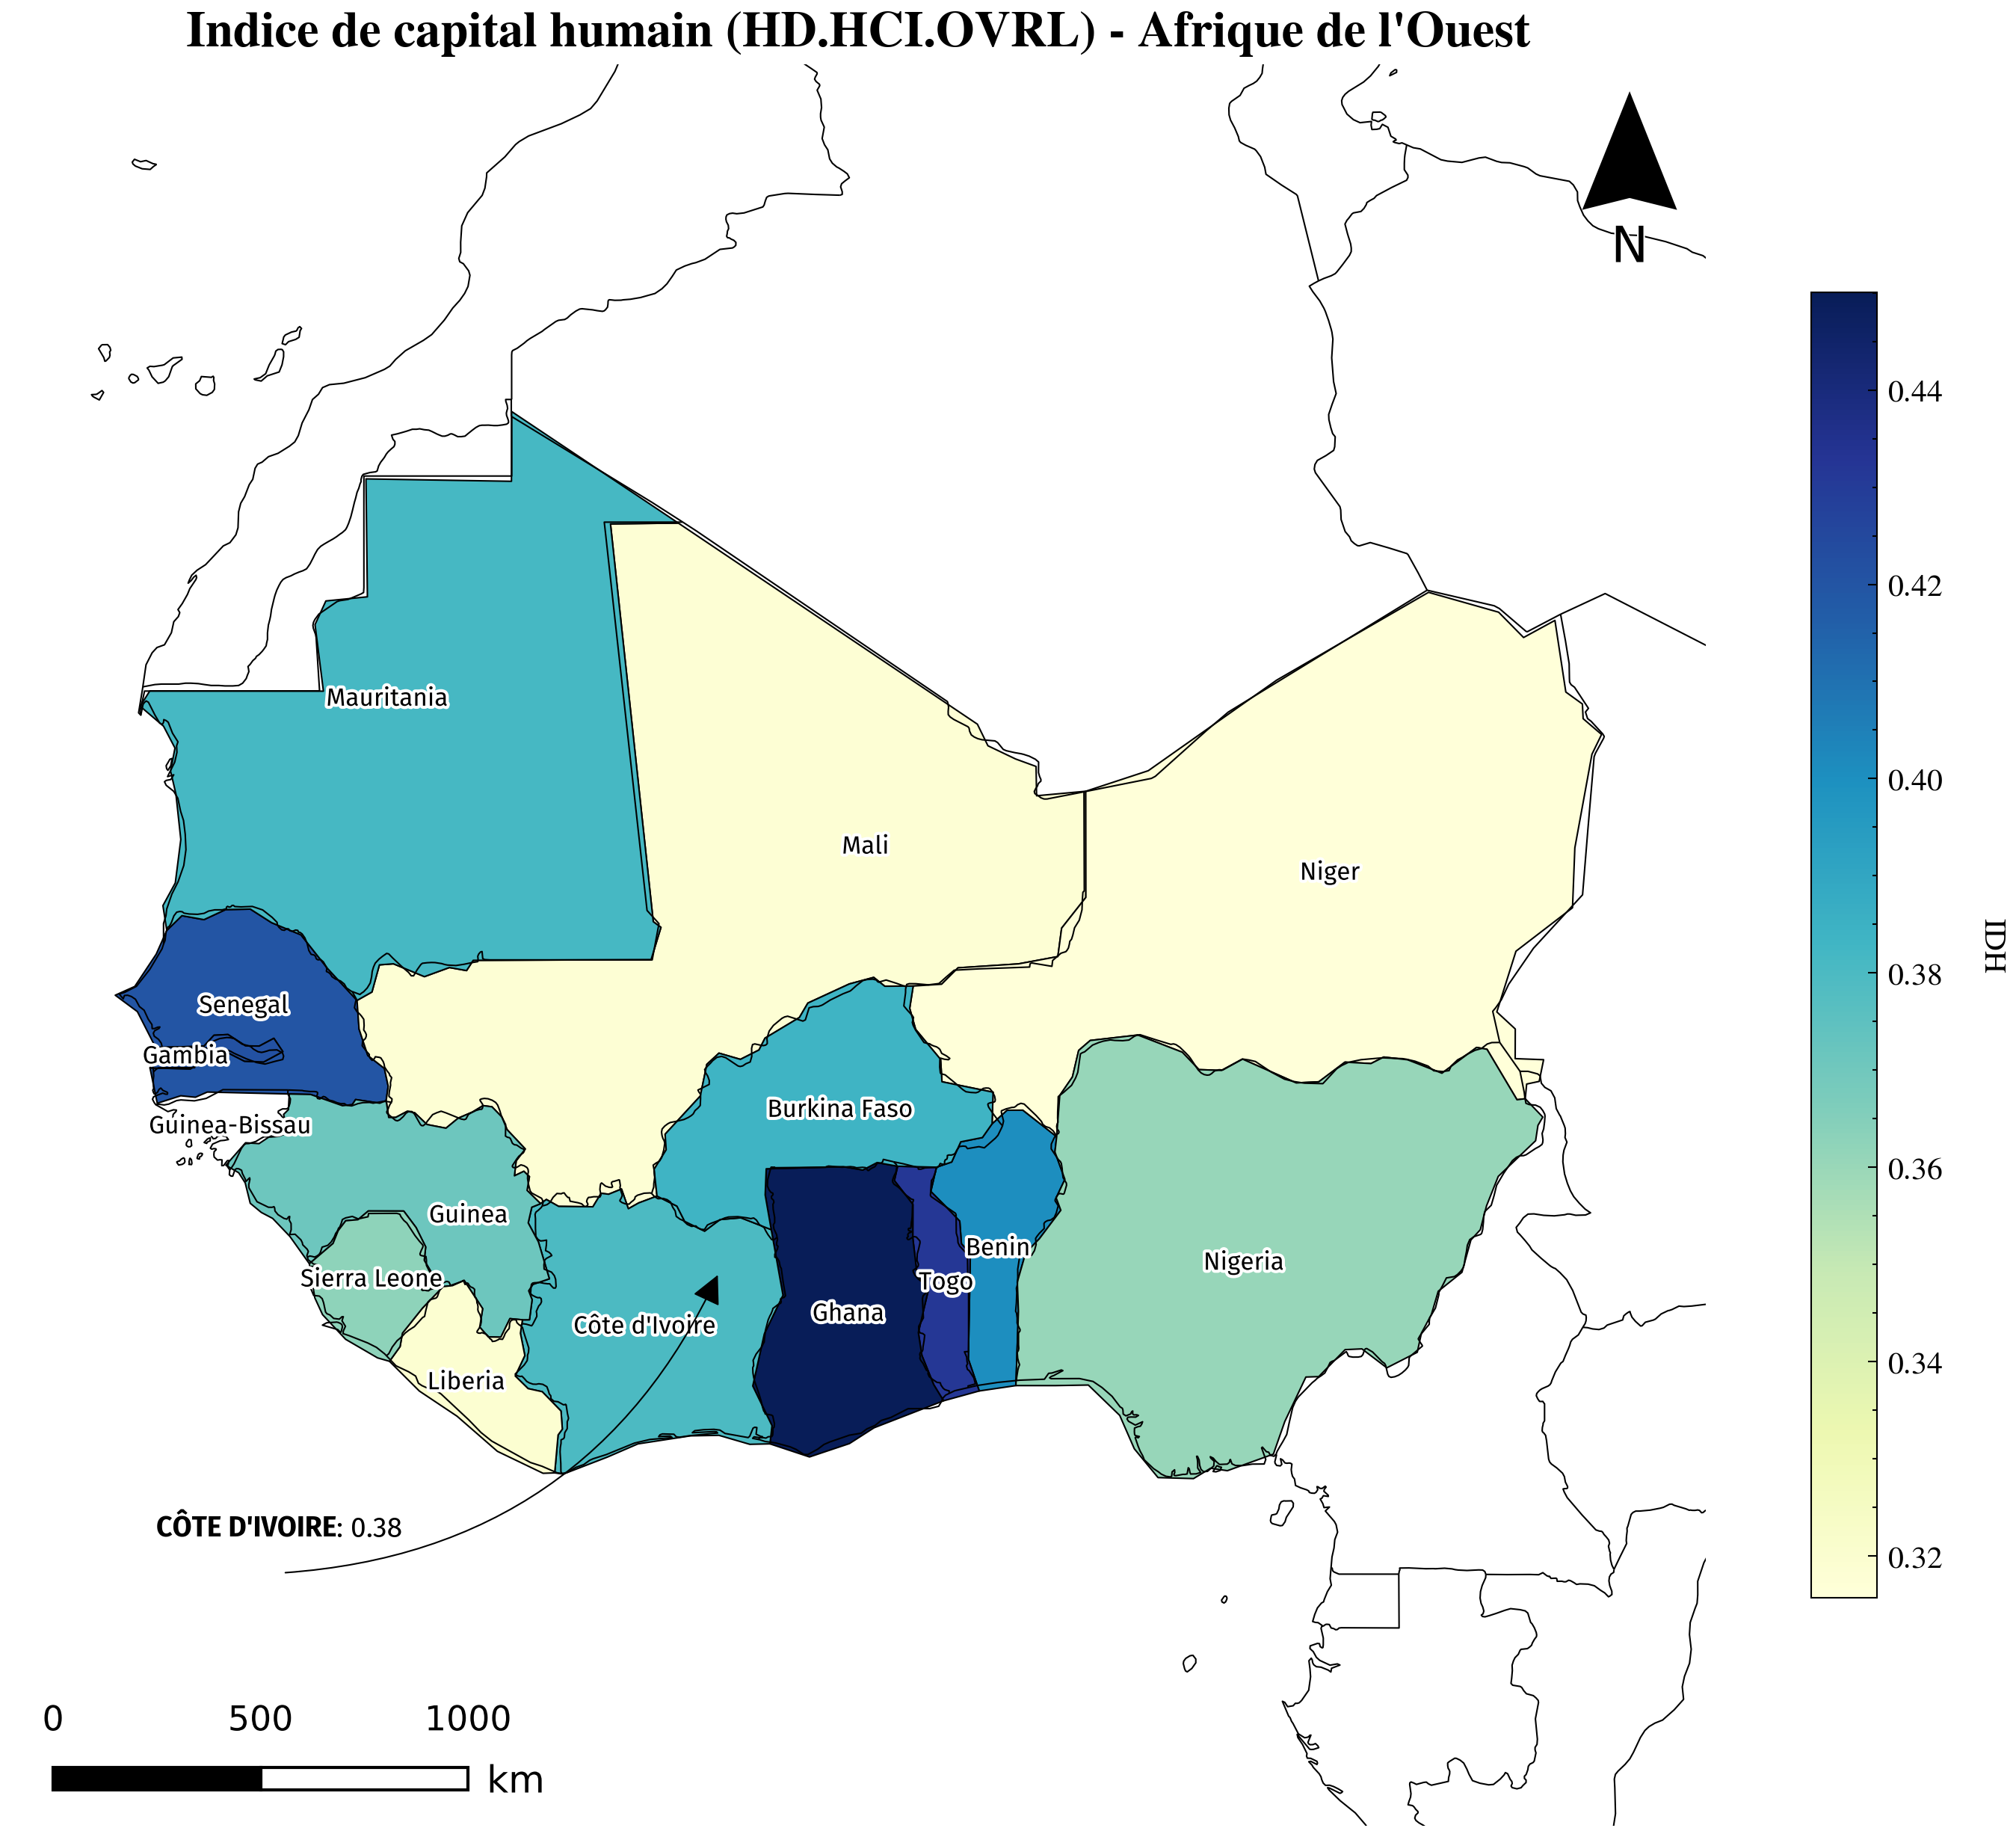

In [15]:
import matplotlib.patheffects as patheffects
import cartograpy as cp
from cartograpy.data import WorldBank, Bound
from cartograpy.mapper import Map
import wbdata

font_labels = cp.google_font("Fira Sans", weight="regular")
font_bold = cp.google_font("Fira Sans", weight="bold")

# ... (chargement idh / gdf inchangé) ...

wb = WorldBank()
bound = Bound()

# --- Données IDH (Banque mondiale) --------------------------------------
idh = wb.get_data({"HD.HCI.OVRL": "IDH"}, country="all")
idh = idh.reset_index().dropna(subset=["IDH"])
idh = idh.sort_values("date", ascending=False).groupby("country", as_index=False).first()

# --- ISO3 pour pouvoir joindre avec la géométrie -------------------------
countries_meta = wbdata.get_countries()
name_to_iso3 = {
    c["name"]: c["id"]
    for c in countries_meta
    if c["region"]["value"] != "Aggregates"
}
idh["iso3"] = idh["country"].map(name_to_iso3)
idh = idh.dropna(subset=["iso3"])

# --- Limites de l'Afrique de l'Ouest -------------------------------------
WEST_AFRICA_ISO3 = [
    "BEN", "BFA", "CPV", "CIV", "GMB", "GHA", "GIN", "GNB",
    "LBR", "MLI", "MRT", "NER", "NGA", "SEN", "SLE", "TGO",
]
world = bound.get_world("country")
west_africa = world[world["iso3"].isin(WEST_AFRICA_ISO3)]
gdf = west_africa.merge(idh[["iso3", "IDH"]], on="iso3", how="left")


m = Map(figsize=(10, 10), title="Indice de capital humain (HD.HCI.OVRL) - Afrique de l'Ouest")
m.add_polygons_choropleth(gdf, column_to_plot="IDH", cmap="YlGnBu", title="IDH", show_labels=False)

# Étiquettes de tous les pays
for _, row in gdf.iterrows():
    point = row.geometry.representative_point()
    m.add_custom_text(
        row["name"], (point.x, point.y), to="ax",
        fontsize=8, color="black", ha="center", va="center",
        font=font_labels,
        path_effects=[patheffects.withStroke(linewidth=2, foreground="white")],
    )

# Flèche hors-carte pointant sur la Côte d'Ivoire, avec son IDH en évidence
civ_row = gdf.loc[gdf["iso3"] == "CIV"].iloc[0]
civ_point = civ_row.geometry.representative_point()

m.fig.canvas.draw()  # force le layout avant de convertir coords carte -> coords figure
head_x, head_y = m.ax.transData.transform((civ_point.x, civ_point.y))
head_position = tuple(m.fig.transFigure.inverted().transform((head_x, head_y)))
tail_position = (0.16, 0.22)

m.add_fig_arrow(
    tail_position=tail_position,
    head_position=head_position,
    radius=0.3,
    width=0.5, head_width=4, head_length=8, color="black",
)
m.add_custom_text(
    f"<CÔTE D'IVOIRE>: {civ_row['IDH']:.2f}", (tail_position[0], tail_position[1] + 0.02), to="fig",
    highlight_textprops=[{"font": font_bold}],
    color="black", fontsize=9, font=font_labels,
    ha="center", va="center",
)

m.add_north_arrow()
m.add_scale_bar()
m.hide_gridline()
m.save("carte_idh.png", bbox_inches=None)  # important, voir note ci-dessous


In [16]:
import pandas as pd

url = "https://zenodo.org/records/17467221/files/Subnational%20HDI%20Data%20v8.3.csv?download=1"
df = pd.read_csv(url)

civ = df[(df["isocode3"] == "CIV") & (df["year"] == 2022) & (df["level"] == "Subnat")]
civ.to_csv("civ_shdi_2022.csv", index=False)
print(civ[["region", "shdi", "healthindex", "edindex", "incindex", "lifexp", "esch", "msch"]])

                   region   shdi  healthindex  edindex  incindex  lifexp  \
13721             Abidjan  0.569        0.636    0.419     0.689  61.324   
13754        Yamoussoukro  0.619        0.643    0.557     0.662  61.793   
13787       Bas Sassandra  0.520        0.614    0.414     0.553  59.918   
13820               Comoe  0.582        0.675    0.475     0.615  63.865   
13853            Denguele  0.440        0.486    0.293     0.598  51.572   
13886         Goh-Djiboua  0.551        0.621    0.458     0.588  60.384   
13919                Lacs  0.542        0.587    0.475     0.571  58.140   
13952             Lagunes  0.566        0.640    0.483     0.586  61.568   
13985           Montagnes  0.492        0.547    0.406     0.536  55.583   
14018  Sassandra-Marahoue  0.512        0.581    0.409     0.565  57.751   
14051             Savanes  0.471        0.573    0.323     0.564  57.257   
14084   Vallee du Bandama  0.554        0.614    0.461     0.602  59.880   
14117       

c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:5808: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout()


                NAME_1  densite  esperance_vie_2022 bi_class
0              Abidjan   2999.3              61.324      3-3
1        Bas-Sassandra     96.7              59.918      2-2
2                Comoé    102.9              63.865      3-3
3             Denguélé     20.6              51.572      1-1
4          Gôh-Djiboua    132.8              60.384      3-2
5                 Lacs     56.9              58.140      1-2
6              Lagunes    102.3              61.568      2-3
7            Montagnes     99.6              55.583      2-1
8   Sassandra-Marahoué    112.0              57.751      3-1
9              Savanes     53.6              57.257      1-1
10   Vallée du Bandama     71.2              59.880      2-2
11              Woroba     37.6              53.549      1-1
12        Yamoussoukro    205.5              61.793      3-3
13              Zanzan     35.4              61.358      1-3


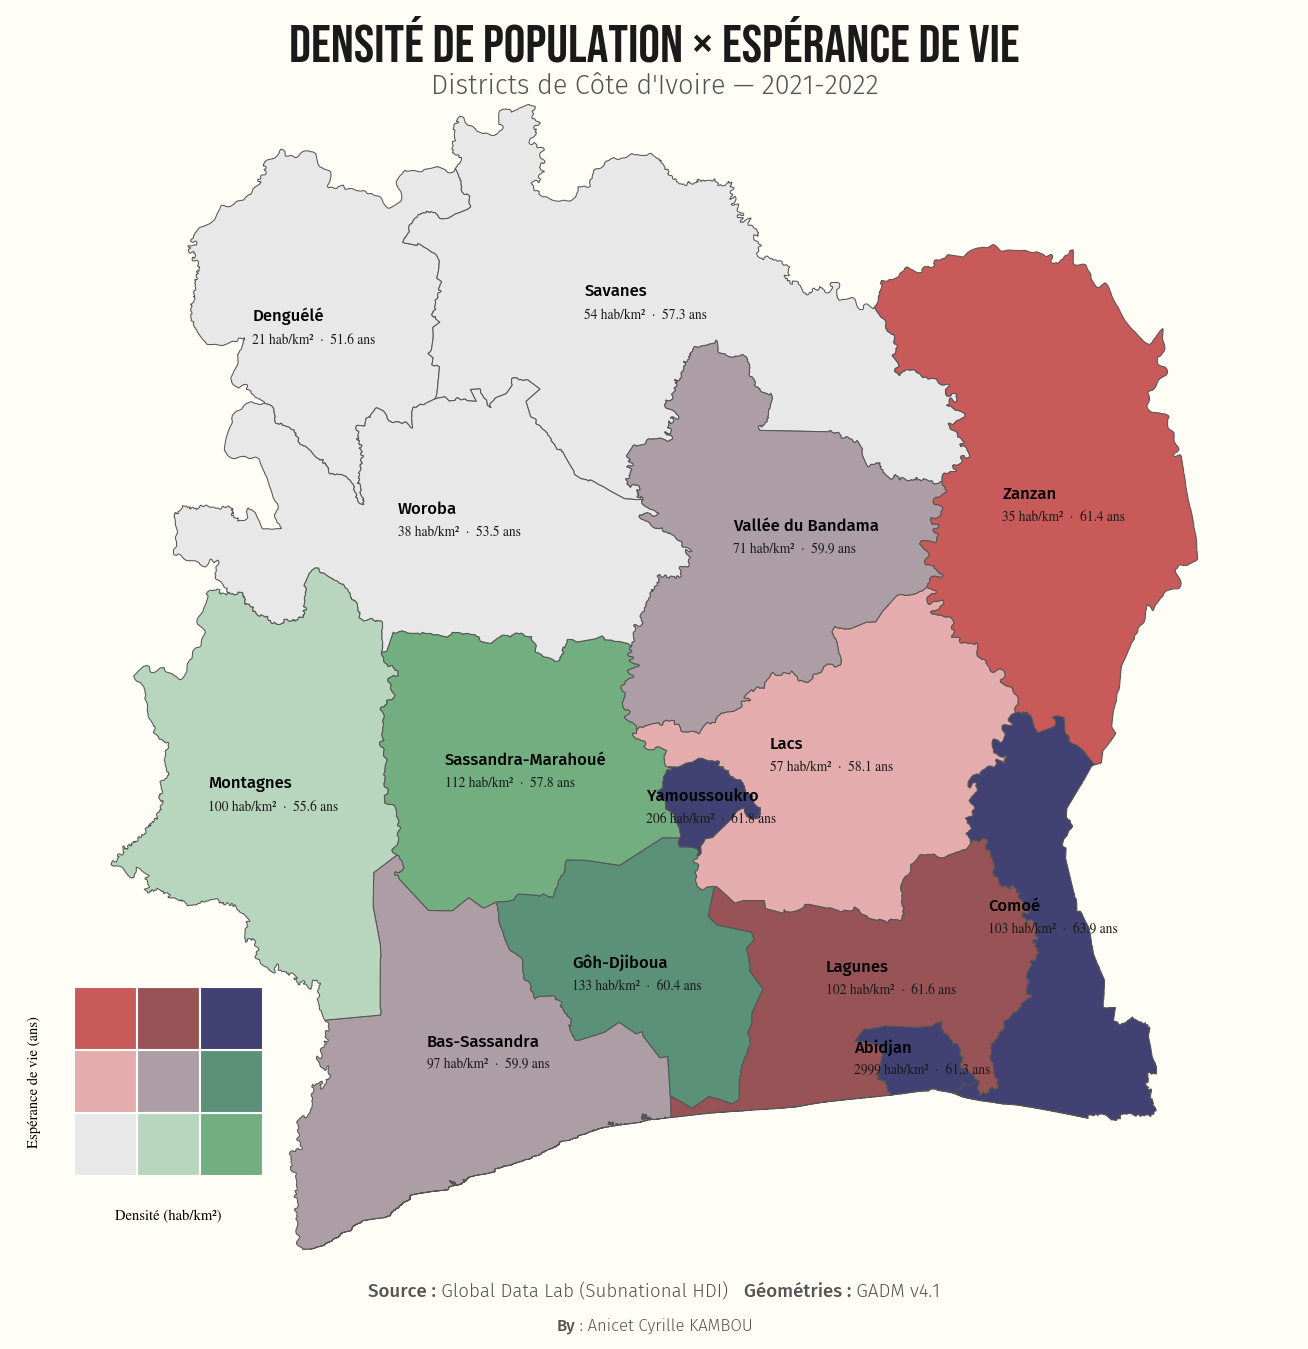

In [17]:
import cartograpy as cp

# --- Données : districts CIV + indicateurs réels (via cp.load, pas geopandas) ---
regions = cp.load("mon_projet_sig/data/vector/gadm_CIV_ADM1_reel.geojson")


# --- Polices ---
font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")

# --- Carte bivariée ---
m = cp.Map(figsize=(9, 9), dpi=150, basemap=False, title="", verbose=False)
m.set_background_color("#FFFEF6")
m.add_bivariate(
    regions, "densite", "esperance_vie_2022",
    var1_label="Densité (hab/km²)", var2_label="Espérance de vie (ans)",
    palette="teal_orange", n_classes=3,
    legend_position=(0.07, 0.13, 0.14, 0.14), legend_fontsize=7,
    edgecolor="#555555", linewidth=0.5,
)

# --- Étiquettes par district (nom en gras + les deux valeurs croisées) ---
m.add_custom_labels(
    regions,
    "<{NAME_1}>\n{densite:.0f} hab/km²  ·  {esperance_vie_2022:.1f} ans",
    fontsize=6.5, color="#1a1a1a", linespacing=1.35,
    highlight_textprops=[{"font": font_bold, "fontsize": 8, "color": "#000000"}],
)

# --- Habillage typographique ---
m.add_custom_text(
    "Densité de population × espérance de vie", (0.5, 0.99), to="fig",
    color="#1a1a1a", fontsize=26, font=font_title, ha="center", va="top",
)
m.add_custom_text(
    "Districts de Côte d'Ivoire — 2021-2022", (0.5, 0.948), to="fig",
    color="#555555", fontsize=13, font=font_text, ha="center", va="top",
)
m.add_custom_text(
    "<Source :> Global Data Lab (Subnational HDI)   <Géométries :> GADM v4.1",
    (0.5, 0.045), to="fig", color="#555555", fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}, {"font": font_bold}],
)
m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.5, 0.02), to="fig",
    color="#555555", fontsize=8, font=font_text, ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

m.save("bivariate-civ.png", dpi=150)

# Classe bivariée de chaque district (ex. "3-3" = densité forte, espérance de vie forte) :
print(m.last_bivariate[["NAME_1", "densite", "esperance_vie_2022", "bi_class"]])

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']
C:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:982: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  return self._add_gdf_layer(
C:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:3353: DeprecationWarning: pathlib.Path.__enter__() is deprecated and scheduled for removal in Python 3.13; Path objects as a context manager is a no-op
  with importlib.resources.files("cartograpy").joinpath(
Can't handle color: param(outline)
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected 

c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartogr

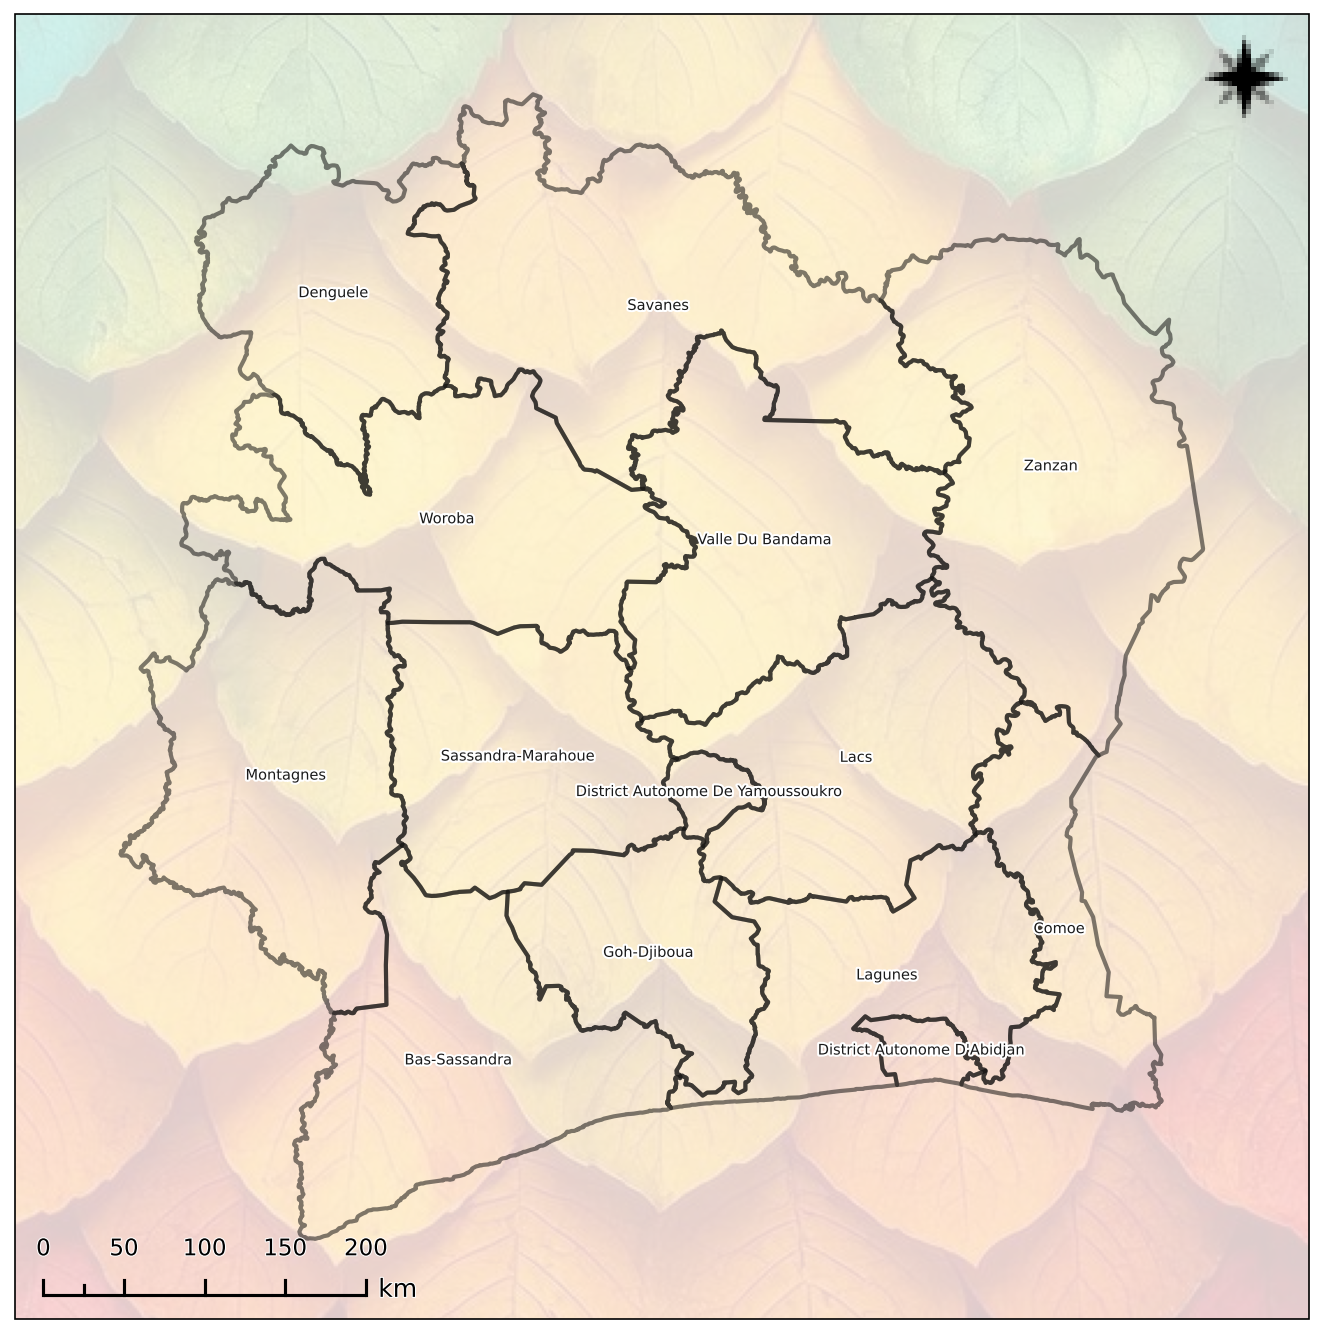

In [1]:
import cartograpy as cp
# from cartograpy.data import Bound

bound = cp.Bound()
civ = bound.get_admin("CIV", adm=1)

m = cp.Map(figsize=(9, 9), dpi=150, basemap=False, title="", verbose=False)
m.add_polygons(civ, facecolor="none", edge_color="#010101", linewidth=2)


# 1) fond coloré pour révéler l'image claire
# m.set_background_color("#000000A9")
# Texture derrière toutes les couches, sur l'étendue courante (self.bounds)
m.add_background_image("télécharger.jpg", alpha=1, zoom=3)

m.add_labels(civ, label_column="shapeName", fontsize=7, color="#1a1a1a")
m.add_north_arrow(style="svg", arrow=12, zoom=0.35)
m.add_scale_bar(style="ticks")

# Ajuster ensuite sans tout ré-écrire
m.set_background_image(alpha=0.2)

m.save("carte_texture.png", dpi=150)
